<a href="https://colab.research.google.com/github/yaswanthvuppala/Quantum-Computing-codes/blob/main/Primitives_in_Qc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install qiskit qiskit_ibm_runtime pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 7.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 5.4 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha25

# Transverse filed lsing model (TFIM) to demo primitives


The Ising Model:
 A Physics Benchmark for Quantum ComputingWhat is the Ising Model?The Ising model is a foundational mathematical model from statistical mechanics. It simplifies a complex magnetic material into a lattice grid where each point holds a microscopic spin pointing either Up (+1) or Down (-1).The system operates under a basic mathematical rule (the Hamiltonian):$$H = -J \sum_{\langle i,j \rangle} Z_i Z_j + h \sum_i X_i$$$J$ (Coupling):
 Determines how strongly neighboring spins want to align with each other.$h$ (Transverse Field): An external magnetic force trying to flip individual spins.The model is highly celebrated because it demonstrates a phase transition: at high temperatures, thermal chaos dominates, while at lower temperatures, cooperative interactions cause the spins to align into an ordered, magnetic state.How is it used in Quantum Computing?The Nature study uses the 2D Transverse-Field Ising Model as a rigorous benchmark to demonstrate "Quantum Utility"—the ability of a noisy quantum computer to solve a problem beyond the reach of brute-force classical supercomputers.It is used in three main ways:The Ultimate Entanglement Test: As time evolves in a 2D Ising model, the spins become exponentially entangled. For classical computers using approximation methods (like Matrix Product States or Isometric Tensor Networks), tracking this massive entanglement becomes impossible. A quantum processor handles this naturally because its qubits natively exist in a superposition of all these states.Hardware Layout Matching: IBM's 127-qubit Eagle processor uses a "heavy-hex" architecture. Because each physical qubit can represent an atomic spin, the physics of the Ising model maps directly onto the physical chip. A quantum gate between two qubits perfectly mimics the magnetic coupling ($J$) between two neighboring atoms.Proving Error Mitigation Works: Because near-term quantum computers suffer from inherent noise, researchers used the Ising model to test Zero-Noise Extrapolation (ZNE). By learning the noise patterns and mathematically scaling them, they successfully extracted accurate data from a noisy 127-qubit system at a scale where classical approximations completely broke down.

In [3]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import  YGate , UnitaryGate

In [5]:
SYGate= UnitaryGate(YGate().power(1/2),label=r"$\sqrt{Y}$")
SYdgGate= UnitaryGate(SYGate.inverse(),label=r"$\sqrt{Y}^\dag$")

In [20]:
def generate_ld_tfim_circuit(num_qubits,num_trotter_steps,rx_angle,trotter_barrier=False,layer_barrier=False):
  qc =QuantumCircuit(num_qubits)
  for trotter_step in range(num_trotter_steps):
    add_lm_tfim_trotter_layer(qc,rx_angle,layer_barrier)
    if trotter_barrier:
      qc.barrier()

  return qc

def add_lm_tfim_trotter_layer(qc,rx_angle,layer_barrier=False):
  #  Adding Rzz in the even layers
  for i in range(0,qc.num_qubits-1,2):
    qc.sdg([i,i+1])
    qc.append(SYGate,[i+1])
    qc.cx(i,i+1)
    qc.append(SYdgGate,[i+1])
  if layer_barrier:
    qc.barrier()

  #  Adding Rzz in the odd layers
  for i in range(1,qc.num_qubits-1,2):
    qc.sdg([i,i+1])
    qc.append(SYGate,[i+1])
    qc.cx(i,i+1)
    qc.append(SYdgGate,[i+1])

  if layer_barrier:
    qc.barrier()

  qc.rx(rx_angle,list(range(qc.num_qubits)))

  if layer_barrier:
    qc.barrier()

In [16]:
import numpy as np

# TFIM

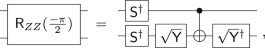

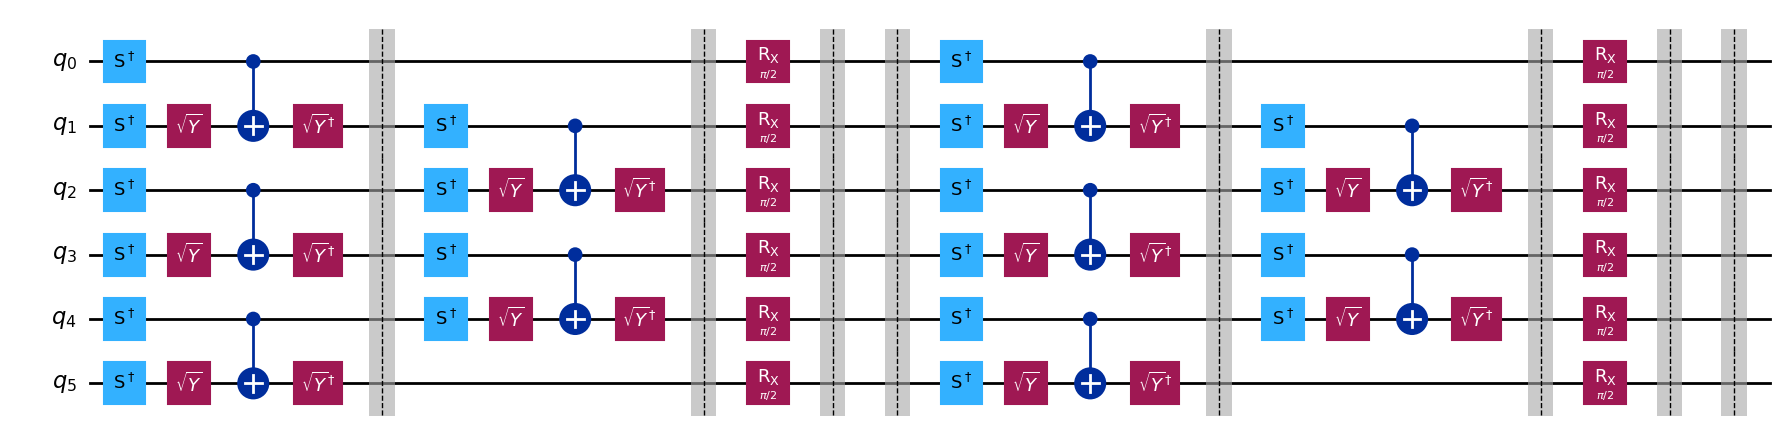

In [32]:
num_qubits=6
num_trotter_steps=2
rx_angle=0.5*np.pi

qc =generate_ld_tfim_circuit(num_qubits,num_trotter_steps,rx_angle,trotter_barrier=True,layer_barrier=True)

qc.draw(output='mpl',fold=-1)

# Without any barriers and trotter steps=1

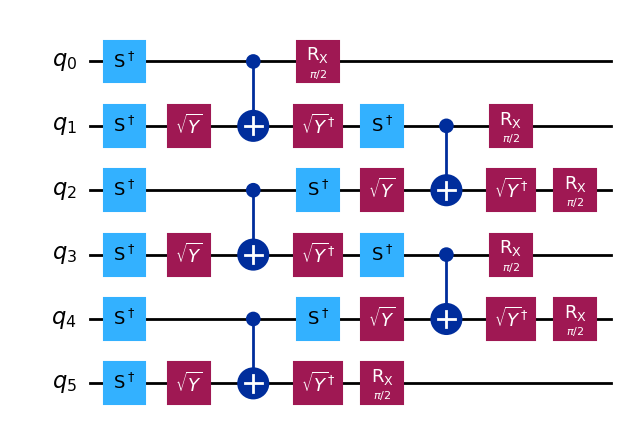

# Demo Sampler

In [33]:
def append_mirrored_ld_tfim_circuit(qc,num_qubits,num_trotter_steps,rx_angle,trotter_barrier=False,layer_barrier=False):
  for trotter_step in range(num_trotter_steps):
    add_mirrored_lm_tfim_trotter_layer(qc,rx_angle,layer_barrier)
    if trotter_barrier:
      qc.barrier()


def add_mirrored_lm_tfim_trotter_layer(qc,rx_angle,layer_barrier=False):

  qc.rx(-rx_angle,list(range(qc.num_qubits)))

  if layer_barrier:
    qc.barrier()

  #  Adding Rzz in the odd layers
  for i in range(1,qc.num_qubits-1,2):

    qc.append(SYdgGate,[i+1])
    qc.cx(i,i+1)
    qc.append(SYGate,[i+1])
    qc.s([i,i+1])




  if layer_barrier:
    qc.barrier()

  #  Adding Rzz in the even layers
  for i in range(0,qc.num_qubits-1,2):
    qc.append(SYdgGate,[i+1])
    qc.cx(i,i+1)
    qc.append(SYGate,[i+1])
    qc.s([i,i+1])
  if layer_barrier:
    qc.barrier()

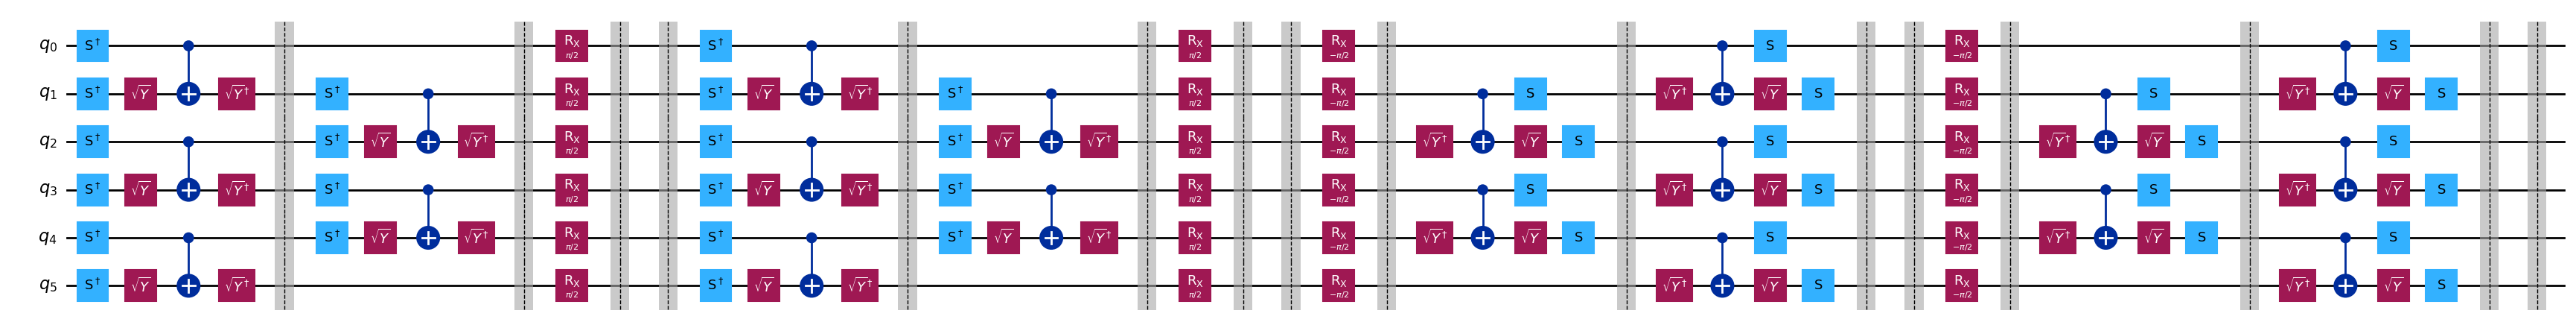

In [34]:
append_mirrored_ld_tfim_circuit(qc,num_qubits,num_trotter_steps,rx_angle,trotter_barrier=True,layer_barrier=True)

qc.draw(output='mpl',fold=-1)